In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.DataFrame({
    'Experience': [1, 3, 5, 7, 10],
    'Projects': [2, 5, 8, 10, 12],
    'Performance': [3, 6, 7, 8, 9],
    'Department': ['HR', 'IT', 'Sales', 'IT', 'HR']
})

correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()


In [ ]:
ValueError: could not convert string to float: 'HR'

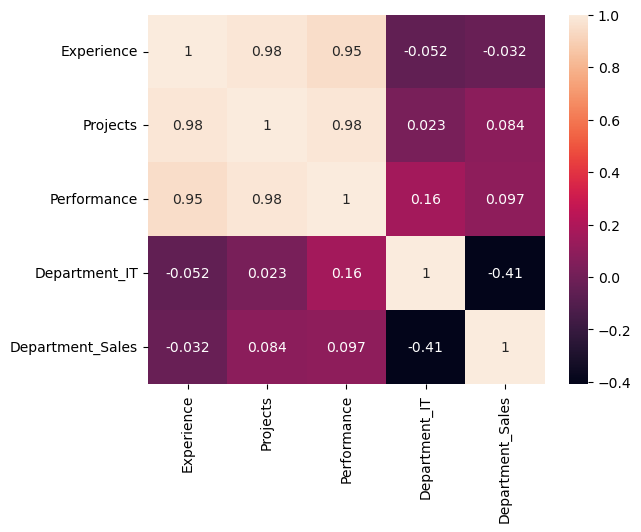

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.DataFrame({
    'Experience': [1, 3, 5, 7, 10],
    'Projects': [2, 5, 8, 10, 12],
    'Performance': [3, 6, 7, 8, 9],
    'Department': ['HR', 'IT', 'Sales', 'IT', 'HR']
})
data = pd.get_dummies(data, columns=['Department'], drop_first=True)
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()


# 2

In [3]:
import pandas as pd
import numpy as np

data = pd.DataFrame({
    'Name': ['John', 'Emily', 'Michael', 'kishor', 'Sarah'],
    'Age': [25, 30, np.nan, 28, 22],
    'Salary': [50000, 60000, 55000, 58000, np.nan]
})

data.fillna(np.mean, inplace=True)
data


C:\Users\jsril\AppData\Local\Temp\ipykernel_46332\1826308632.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<function mean at 0x000001AACE37B600>' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.fillna(np.mean, inplace=True)


,Name,Age,Salary
0,John,25.0,50000.0
1,Emily,30.0,60000.0
2,Michael,<function mean at 0x000001AACE37B600>,55000.0
3,kishor,28.0,58000.0
4,Sarah,22.0,<function mean at 0x000001AACE37B600>


In [ ]:
Remove the null values using the mean of the respective columns.


In [2]:
import pandas as pd
import numpy as np

data = pd.DataFrame({
    'Name': ['John', 'Emily', 'Michael', 'kishor', 'Sarah'],
    'Age': [25, 30, np.nan, 28, 22],
    'Salary': [50000, 60000, 55000, 58000, np.nan]
})

data['Age'].fillna(data['Age'].mean(), inplace=True)
data['Salary'].fillna(data['Salary'].mean(), inplace=True)


C:\Users\jsril\AppData\Local\Temp\ipykernel_29104\789345349.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
C:\Users\jsril\AppData\Local\Temp\ipykernel_29104\789345349.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [3]:
data

,Name,Age,Salary
0,John,25.00,50000.0
1,Emily,30.00,60000.0
2,Michael,26.25,55000.0
3,kishor,28.00,58000.0
4,Sarah,22.00,55750.0


# 3

In [ ]:
from scipy import stats

group1 = [120, 125, 130, 122, 128]
group2 = [110, 115, 108, 102, 107]

t_stat, p_value = stats.ttest_ind(group1, group2, axis=1)
print(f"T-Statistic: {t_stat}, P-Value: {p_value}")

if p_value <= 0.05:
    print("Reject the null hypothesis: Significant difference.")
else:
    print("Fail to reject the null hypothesis: No significant difference.")


In [ ]:
AxisError : axis 1 is out of bounds for array of dimension 1

In [4]:
from scipy import stats

group1 = [120, 125, 130, 122, 128]
group2 = [110, 115, 108, 102, 107]

t_stat, p_value = stats.ttest_ind(group1, group2, axis=0)
print(f"T-Statistic: {t_stat}, P-Value: {p_value}")

if p_value <= 0.05:
    print("Reject the null hypothesis: Significant difference.")
else:
    print("Fail to reject the null hypothesis: No significant difference.")


T-Statistic: 5.921023912553299, P-Value: 0.0003532844625064416
Reject the null hypothesis: Significant difference.


# 4

In [5]:
import pandas as pd
import numpy as np

data = pd.DataFrame({'Salary': [30000, 32000, 34000, 500000, 36000, 37000, 39000, 41000, 42000, 450000]})

outlier_threshold = data['Salary'].mean() + 3 * data['Salary'].std()
outliers = data[data['Salary'] > outlier_threshold]

print("Outliers:", outliers)


Outliers: Empty DataFrame
Columns: [Salary]
Index: []


In [12]:
Q1 = data['Salary'].quantile(0.25)
Q3 = data['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data['Salary'] < lower_bound) | (data['Salary'] > upper_bound)
]

print(outliers)


   Salary   z_score
3  500000  2.028018
9  450000  1.758263


In [8]:
mean_salary = data['Salary'].mean()
std_salary = data['Salary'].std()
data['z_score'] = (data['Salary'] - mean_salary) / std_salary
outliers = data[data['z_score'] > 2]

print(outliers)


   Salary   z_score
3  500000  2.028018


In [4]:
import pandas as pd
import numpy as np

data = pd.DataFrame({'Salary': [30000, 32000, 34000, 500000, 36000, 37000, 39000, 41000, 42000, 450000]})

outlier_threshold = data['Salary'].mean() + 3 * data['Salary'].std()

print(outlier_threshold)
print(3 * data['Salary'].std())
outliers = data[data['Salary'] > outlier_threshold]

print("Outliers:", outliers)


680160.1586159541
556060.1586159541
Outliers: Empty DataFrame
Columns: [Salary]
Index: []


# 5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = np.random.normal(50, 10, 1000)

plt.hist()
plt.title("PDF Plot")
plt.show()


In [ ]:
TypeError: hist() missing 1 required positional argument: 'x'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = np.random.normal(50, 10, 1000)

plt.hist(data)
plt.title("PDF Plot")
plt.show()
